# Let's Build a Quant Trading Strategy

## Part 1: Build a ML Model in PyTorch for QQQ

In [207]:
# y_hat = model(x)
# orders = strategy(y_hat)
# execute(orders)

In [208]:
# regression model => QQQ => future log return

In [209]:
# Data and analysis libraries
import polars as pl                         # Fast dataframes for financial data
import numpy as np                          # Numerical computing library
from datetime import datetime, timedelta    # Date and time operations
import random

# Machine learning libraries
import torch                                # PyTorch framework
import torch.nn as nn                       # Neural network modules
import torch.optim as optim                 # Optimization algorithms
import research                             # Model building and training utilities

# Visualization
import altair as alt                        # Interactive visualization library

# Data source for QQQ (stock ETF)
import yfinance as yf                       # Yahoo Finance market data

In [210]:
import altair as alt
print(alt.__version__)

6.0.0


In [211]:
research.set_seed(42)

In [212]:
pl.Config.set_tbl_width_chars(200)
pl.Config.set_fmt_str_lengths(100)
pl.Config.set_tbl_cols(-1)  # Show all columns

polars.config.Config

In [213]:
# Trading symbol
sym = 'QQQ'
# time horizon of time series (daily bars for stock ETF)
time_interval = '1d'
# Max number of auto-regressive lags
max_lags = 4
# Forecast horizon in steps
forecast_horizon = 1
# Sharpe annualized rate for stocks (252 trading days, ~6.5 hours/day)
annualized_rate = research.sharpe_annualization_factor(time_interval, 252, 6.5)

In [214]:
# Download QQQ daily OHLC data from Yahoo Finance
start_date = datetime(2023, 10, 29)
end_date = datetime(2025, 10, 9)

qqq_data = yf.download(sym, start=start_date, end=end_date, interval='1d')
qqq_data.head()


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,QQQ,QQQ,QQQ,QQQ,QQQ
Date,,,,,
2023-10-30,344.515747,345.837768,341.802636,343.164099,55298500
2023-10-31,346.163300,346.538207,341.970311,344.545315,47671900
2023-11-01,352.171661,352.734023,346.903297,347.001961,58992700
2023-11-02,358.564697,358.801468,355.466804,356.690191,58162400
2023-11-03,362.777374,364.069799,359.630164,359.857089,53280500


In [215]:
# Convert Yahoo Finance pandas DataFrame to Polars DataFrame
# Match the format expected by research module (datetime, open, high, low, close)
ts = pl.DataFrame({
    'datetime': qqq_data.index.to_pydatetime().tolist(),
    'open': qqq_data['Open'].values.flatten().astype(float),
    'high': qqq_data['High'].values.flatten().astype(float),
    'low': qqq_data['Low'].values.flatten().astype(float),
    'close': qqq_data['Close'].values.flatten().astype(float),
}).with_columns(pl.col('datetime').cast(pl.Datetime))
ts

datetime,open,high,low,close
datetime[μs],f64,f64,f64,f64
2023-10-30 00:00:00,343.164099,345.837768,341.802636,344.515747
2023-10-31 00:00:00,344.545315,346.538207,341.970311,346.1633
2023-11-01 00:00:00,347.001961,352.734023,346.903297,352.171661
2023-11-02 00:00:00,356.690191,358.801468,355.466804,358.564697
2023-11-03 00:00:00,359.857089,364.069799,359.630164,362.777374
…,…,…,…,…
2025-10-02 00:00:00,606.278867,606.378714,602.154177,604.950562
2025-10-03 00:00:00,605.729602,606.548554,600.616195,602.40387
2025-10-06 00:00:00,607.667078,608.57588,605.190227,606.92804


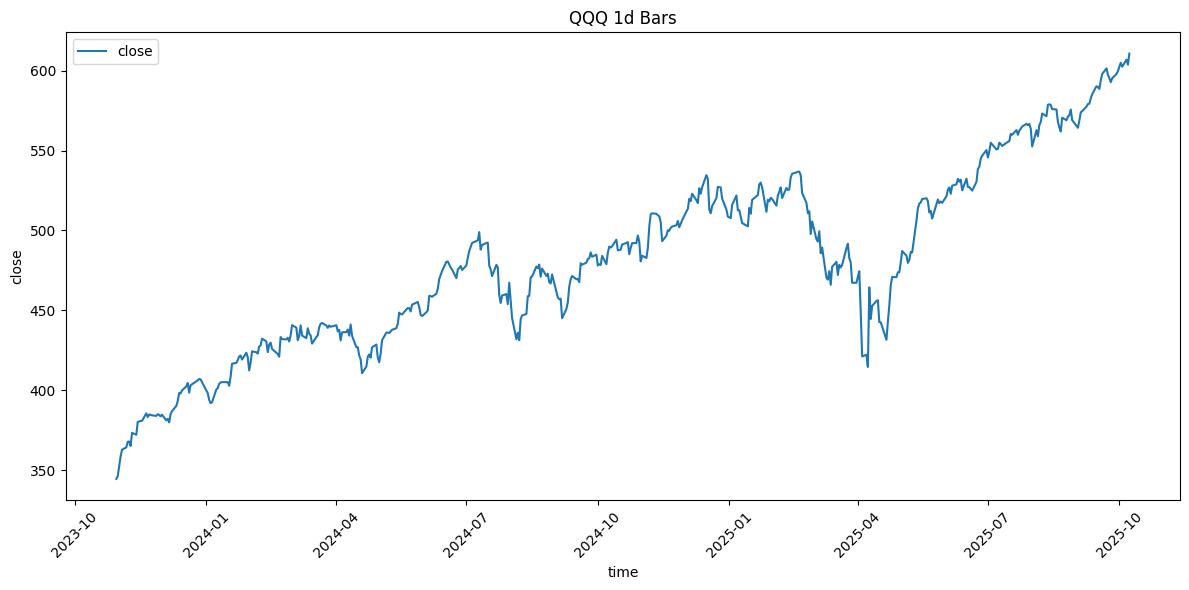

In [216]:
research.plot_static_timeseries(ts, sym, 'close', time_interval)

In [217]:
alt.data_transformers.enable("vegafusion")
research.plot_dyn_timeseries(ts, sym, 'close', time_interval)

alt.Chart(...)

### Feature Engineering

In [218]:
price_time_series = pl.DataFrame({'price':[100.0,120.0,100.0]})
research.plot_column(price_time_series, 'price')

alt.Chart(...)

In [219]:
price_time_series.with_columns(
    pl.col('price').diff().alias('delta'),
    ((pl.col('price')-pl.col('price').shift())/pl.col('price').shift()).alias('return'),
    (pl.col('price')/pl.col('price').shift()).log().alias('log_return'),
)

price,delta,return,log_return
f64,f64,f64,f64
100.0,null,null,null
120.0,20.0,0.2,0.182322
100.0,-20.0,-0.166667,-0.182322


### Create target and lagged features

In [220]:
ts = ts.with_columns((pl.col('close')/pl.col('close').shift(forecast_horizon)).log().alias('close_log_return'))
ts

datetime,open,high,low,close,close_log_return
datetime[μs],f64,f64,f64,f64,f64
2023-10-30 00:00:00,343.164099,345.837768,341.802636,344.515747,null
2023-10-31 00:00:00,344.545315,346.538207,341.970311,346.1633,0.004771
2023-11-01 00:00:00,347.001961,352.734023,346.903297,352.171661,0.017208
2023-11-02 00:00:00,356.690191,358.801468,355.466804,358.564697,0.01799
2023-11-03 00:00:00,359.857089,364.069799,359.630164,362.777374,0.01168
…,…,…,…,…,…
2025-10-02 00:00:00,606.278867,606.378714,602.154177,604.950562,0.004103
2025-10-03 00:00:00,605.729602,606.548554,600.616195,602.40387,-0.004219
2025-10-06 00:00:00,607.667078,608.57588,605.190227,606.92804,0.007482


In [221]:
target = 'close_log_return'
lr = pl.col(target)
ts = ts.with_columns(
    lr.shift(forecast_horizon * 1).alias(f'{target}_lag_1'),
    lr.shift(forecast_horizon * 2).alias(f'{target}_lag_2'),
    lr.shift(forecast_horizon * 3).alias(f'{target}_lag_3'),
    lr.shift(forecast_horizon * 4).alias(f'{target}_lag_4'),
)
ts

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2023-10-30 00:00:00,343.164099,345.837768,341.802636,344.515747,null,null,null,null,null
2023-10-31 00:00:00,344.545315,346.538207,341.970311,346.1633,0.004771,null,null,null,null
2023-11-01 00:00:00,347.001961,352.734023,346.903297,352.171661,0.017208,0.004771,null,null,null
2023-11-02 00:00:00,356.690191,358.801468,355.466804,358.564697,0.01799,0.017208,0.004771,null,null
2023-11-03 00:00:00,359.857089,364.069799,359.630164,362.777374,0.01168,0.01799,0.017208,0.004771,null
…,…,…,…,…,…,…,…,…,…
2025-10-02 00:00:00,606.278867,606.378714,602.154177,604.950562,0.004103,0.004786,0.002735,0.00462,0.004103
2025-10-03 00:00:00,605.729602,606.548554,600.616195,602.40387,-0.004219,0.004103,0.004786,0.002735,0.00462
2025-10-06 00:00:00,607.667078,608.57588,605.190227,606.92804,0.007482,-0.004219,0.004103,0.004786,0.002735


In [222]:
ts = research.add_lags(ts, target, max_lags, forecast_horizon)
ts

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2023-10-30 00:00:00,343.164099,345.837768,341.802636,344.515747,null,null,null,null,null
2023-10-31 00:00:00,344.545315,346.538207,341.970311,346.1633,0.004771,null,null,null,null
2023-11-01 00:00:00,347.001961,352.734023,346.903297,352.171661,0.017208,0.004771,null,null,null
2023-11-02 00:00:00,356.690191,358.801468,355.466804,358.564697,0.01799,0.017208,0.004771,null,null
2023-11-03 00:00:00,359.857089,364.069799,359.630164,362.777374,0.01168,0.01799,0.017208,0.004771,null
…,…,…,…,…,…,…,…,…,…
2025-10-02 00:00:00,606.278867,606.378714,602.154177,604.950562,0.004103,0.004786,0.002735,0.00462,0.004103
2025-10-03 00:00:00,605.729602,606.548554,600.616195,602.40387,-0.004219,0.004103,0.004786,0.002735,0.00462
2025-10-06 00:00:00,607.667078,608.57588,605.190227,606.92804,0.007482,-0.004219,0.004103,0.004786,0.002735


In [223]:
ts = ts.drop_nulls()

In [224]:
research.plot_distribution(ts, target, no_bins = 100)

alt.Chart(...)

In [225]:
research.plot_distribution(ts, 'close', no_bins = 100)

alt.Chart(...)

### Build Model

In [226]:
class LinearModel(nn.Module):
    def __init__(self, input_features):
        super(LinearModel, self).__init__()
        self.linear = nn.Linear(input_features, 1)

    def forward(self, x):
        return self.linear(x)

### Complexity of the model

In [227]:
input_features = 1

linear_model = LinearModel(input_features)

research.print_model_info(linear_model, "Linear Model")
research.total_model_params(linear_model)


Linear Model

Architecture:
  LinearModel(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)

Parameter Count:
  Total parameters:      2
  Trainable parameters:  2



2

In [228]:
# y = w * x + b

### Split by time

In [229]:
features = ['close_log_return_lag_1']
target = 'close_log_return'
test_size = 0.25

In [230]:
len(ts)

482

In [231]:
int(len(ts) * test_size)

120

In [232]:
split_idx = int(len(ts) * (1-test_size))
split_idx

361

In [233]:
ts_train, ts_test = ts[:split_idx], ts[split_idx:]

In [234]:
ts_train

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2023-11-06 00:00:00,363.54692,364.819624,361.988128,364.257263,0.004071,0.01168,0.01799,0.017208,0.004771
2023-11-07 00:00:00,365.303074,368.568671,364.099439,367.7005,0.009408,0.004071,0.01168,0.01799,0.017208
2023-11-08 00:00:00,368.075393,368.77589,365.6484,367.937286,0.000644,0.009408,0.004071,0.01168,0.01799
2023-11-09 00:00:00,368.627892,369.772305,364.612481,365.105774,-0.007725,0.000644,0.009408,0.004071,0.01168
2023-11-10 00:00:00,366.832273,373.46213,366.299509,373.314148,0.022233,-0.007725,0.000644,0.009408,0.004071
…,…,…,…,…,…,…,…,…,…
2025-04-09 00:00:00,414.089647,466.163464,413.950131,464.339996,0.113356,-0.018173,0.00241,-0.064121,-0.05502
2025-04-10 00:00:00,451.944291,453.967059,431.088857,444.590576,-0.043463,0.113356,-0.018173,0.00241,-0.064121
2025-04-11 00:00:00,443.066043,454.166374,439.757862,452.781311,0.018255,-0.043463,0.113356,-0.018173,0.00241


In [235]:
ts_test

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-04-16 00:00:00,447.430447,451.007654,436.200604,442.597717,-0.030617,0.001114,0.006755,0.018255,-0.043463
2025-04-17 00:00:00,445.577077,446.154997,439.787745,442.518005,-0.00018,-0.030617,0.001114,0.006755,0.018255
2025-04-21 00:00:00,436.668895,437.515842,426.405568,431.567108,-0.025058,-0.00018,-0.030617,0.001114,0.006755
2025-04-22 00:00:00,437.256826,445.9856,436.061089,442.896667,0.025913,-0.025058,-0.00018,-0.030617,0.001114
2025-04-23 00:00:00,456.537891,461.729323,451.266727,452.940735,0.022425,0.025913,-0.025058,-0.00018,-0.030617
…,…,…,…,…,…,…,…,…,…
2025-10-02 00:00:00,606.278867,606.378714,602.154177,604.950562,0.004103,0.004786,0.002735,0.00462,0.004103
2025-10-03 00:00:00,605.729602,606.548554,600.616195,602.40387,-0.004219,0.004103,0.004786,0.002735,0.00462
2025-10-06 00:00:00,607.667078,608.57588,605.190227,606.92804,0.007482,-0.004219,0.004103,0.004786,0.002735


In [236]:
X_train = torch.tensor(ts_train[features].to_numpy(), dtype=torch.float32)
X_test = ts_test[features].to_torch().float()
y_train = torch.tensor(ts_train[target].to_numpy(), dtype=torch.float32)
y_test = torch.tensor(ts_test[target].to_numpy(), dtype=torch.float32)

In [237]:
X_train

tensor([[ 1.1680e-02],
        [ 4.0710e-03],
        [ 9.4084e-03],
        [ 6.4376e-04],
        [-7.7254e-03],
        [ 2.2233e-02],
        [-3.1232e-03],
        [ 2.1298e-02],
        [ 7.5230e-04],
        [ 8.5529e-04],
        [ 2.3328e-04],
        [ 1.2101e-02],
        [-5.8266e-03],
        [ 4.0848e-03],
        [-1.4109e-03],
        [-8.7330e-04],
        [ 2.6175e-03],
        [-9.7445e-04],
        [-2.5171e-03],
        [ 2.8508e-03],
        [-9.3270e-03],
        [ 2.5077e-03],
        [-5.8007e-03],
        [ 1.3876e-02],
        [ 4.4468e-03],
        [ 8.5058e-03],
        [ 7.9328e-03],
        [ 1.2637e-02],
        [-8.6720e-04],
        [ 4.8224e-03],
        [ 6.2788e-03],
        [ 5.0967e-03],
        [-1.4971e-02],
        [ 1.1568e-02],
        [ 1.4950e-03],
        [ 6.1030e-03],
        [ 2.0336e-03],
        [-4.8622e-04],
        [-4.3371e-03],
        [-1.7067e-02],
        [-1.0638e-02],
        [-5.1597e-03],
        [ 1.1853e-03],
        [ 2

In [238]:
X_train.shape

torch.Size([361, 1])

In [239]:
y_train

tensor([ 4.0710e-03,  9.4084e-03,  6.4376e-04, -7.7254e-03,  2.2233e-02,
        -3.1232e-03,  2.1298e-02,  7.5230e-04,  8.5529e-04,  2.3328e-04,
         1.2101e-02, -5.8266e-03,  4.0848e-03, -1.4109e-03, -8.7330e-04,
         2.6175e-03, -9.7445e-04, -2.5171e-03,  2.8508e-03, -9.3270e-03,
         2.5077e-03, -5.8007e-03,  1.3876e-02,  4.4468e-03,  8.5058e-03,
         7.9328e-03,  1.2637e-02, -8.6720e-04,  4.8224e-03,  6.2788e-03,
         5.0967e-03, -1.4971e-02,  1.1568e-02,  1.4950e-03,  6.1030e-03,
         2.0336e-03, -4.8622e-04, -4.3371e-03, -1.7067e-02, -1.0638e-02,
        -5.1597e-03,  1.1853e-03,  2.0457e-02,  1.9736e-03,  6.7547e-03,
         2.0787e-03,  5.1272e-04, -9.7716e-05, -5.6567e-03,  1.4094e-02,
         1.9637e-02,  1.3052e-03,  4.1408e-03,  5.5339e-03,  1.2205e-03,
        -5.9754e-03,  1.0188e-02, -6.6789e-03, -1.9780e-02,  1.1707e-02,
         1.6759e-02, -1.3060e-03, -2.0094e-03,  1.0238e-02,  1.8503e-03,
         9.7948e-03, -3.9202e-03, -1.5720e-02,  1.0

In [240]:
y_train.shape

torch.Size([361])

In [241]:
y_train = y_train.reshape(-1, 1)
y_train

tensor([[ 4.0710e-03],
        [ 9.4084e-03],
        [ 6.4376e-04],
        [-7.7254e-03],
        [ 2.2233e-02],
        [-3.1232e-03],
        [ 2.1298e-02],
        [ 7.5230e-04],
        [ 8.5529e-04],
        [ 2.3328e-04],
        [ 1.2101e-02],
        [-5.8266e-03],
        [ 4.0848e-03],
        [-1.4109e-03],
        [-8.7330e-04],
        [ 2.6175e-03],
        [-9.7445e-04],
        [-2.5171e-03],
        [ 2.8508e-03],
        [-9.3270e-03],
        [ 2.5077e-03],
        [-5.8007e-03],
        [ 1.3876e-02],
        [ 4.4468e-03],
        [ 8.5058e-03],
        [ 7.9328e-03],
        [ 1.2637e-02],
        [-8.6720e-04],
        [ 4.8224e-03],
        [ 6.2788e-03],
        [ 5.0967e-03],
        [-1.4971e-02],
        [ 1.1568e-02],
        [ 1.4950e-03],
        [ 6.1030e-03],
        [ 2.0336e-03],
        [-4.8622e-04],
        [-4.3371e-03],
        [-1.7067e-02],
        [-1.0638e-02],
        [-5.1597e-03],
        [ 1.1853e-03],
        [ 2.0457e-02],
        [ 1

In [242]:
y_train.shape

torch.Size([361, 1])

In [243]:
y_test = y_test.reshape(-1, 1)
y_test

tensor([[-0.0306],
        [-0.0002],
        [-0.0251],
        [ 0.0259],
        [ 0.0224],
        [ 0.0277],
        [ 0.0111],
        [-0.0003],
        [ 0.0066],
        [-0.0001],
        [ 0.0130],
        [ 0.0147],
        [-0.0060],
        [-0.0093],
        [ 0.0039],
        [ 0.0103],
        [-0.0007],
        [ 0.0399],
        [ 0.0151],
        [ 0.0060],
        [ 0.0011],
        [ 0.0043],
        [ 0.0010],
        [-0.0033],
        [-0.0140],
        [ 0.0019],
        [-0.0093],
        [ 0.0233],
        [-0.0044],
        [ 0.0020],
        [-0.0016],
        [ 0.0079],
        [ 0.0078],
        [ 0.0028],
        [-0.0076],
        [ 0.0097],
        [ 0.0015],
        [ 0.0066],
        [-0.0034],
        [ 0.0023],
        [-0.0126],
        [ 0.0138],
        [-0.0098],
        [-0.0002],
        [-0.0041],
        [ 0.0102],
        [ 0.0152],
        [ 0.0026],
        [ 0.0093],
        [ 0.0034],
        [ 0.0065],
        [-0.0085],
        [ 0.

In [244]:
research.timeseries_train_test_split(ts, features, target, test_size)

(tensor([[ 1.1680e-02],
         [ 4.0710e-03],
         [ 9.4084e-03],
         [ 6.4376e-04],
         [-7.7254e-03],
         [ 2.2233e-02],
         [-3.1232e-03],
         [ 2.1298e-02],
         [ 7.5230e-04],
         [ 8.5529e-04],
         [ 2.3328e-04],
         [ 1.2101e-02],
         [-5.8266e-03],
         [ 4.0848e-03],
         [-1.4109e-03],
         [-8.7330e-04],
         [ 2.6175e-03],
         [-9.7445e-04],
         [-2.5171e-03],
         [ 2.8508e-03],
         [-9.3270e-03],
         [ 2.5077e-03],
         [-5.8007e-03],
         [ 1.3876e-02],
         [ 4.4468e-03],
         [ 8.5058e-03],
         [ 7.9328e-03],
         [ 1.2637e-02],
         [-8.6720e-04],
         [ 4.8224e-03],
         [ 6.2788e-03],
         [ 5.0967e-03],
         [-1.4971e-02],
         [ 1.1568e-02],
         [ 1.4950e-03],
         [ 6.1030e-03],
         [ 2.0336e-03],
         [-4.8622e-04],
         [-4.3371e-03],
         [-1.7067e-02],
         [-1.0638e-02],
         [-5.159

### Batch Gradient Descent

In [245]:
# hyperparameters
no_epochs = 1000 * 5
lr = 0.0005

# create model
model = LinearModel(len(features))
# loss function
criterion = nn.MSELoss()
# optimizer
optimizer = optim.Adam(model.parameters(), lr = lr)

print("\nTraining model...")

for epoch in range(no_epochs):
    # forward pass
    y_hat = model(X_train)
    loss = criterion(y_hat, y_train)

    # backward pass
    optimizer.zero_grad()   # 1. clear old gradients
    loss.backward()         # 2. compute new gradients
    optimizer.step()        # 3. update weights

    # check for improvement
    train_loss = loss.item()

    # logging
    if (epoch + 1) % 500 == 0:
        print(f"Epoch [{epoch+1}/{no_epochs}], Loss: {train_loss:.6f}")

print("\nLearned parameters")

for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"{name}:\n{param.data.numpy()}")

# Evaluation
model.eval()
with torch.no_grad():
    y_hat = model(X_test)
    test_loss = criterion(y_hat, y_test)
    print(f"\nTest Loss: {test_loss.item():.6f}, Train Loss: {train_loss:.6f}")


Training model...
Epoch [500/5000], Loss: 0.467911
Epoch [1000/5000], Loss: 0.234001
Epoch [1500/5000], Loss: 0.101470
Epoch [2000/5000], Loss: 0.036160
Epoch [2500/5000], Loss: 0.009917
Epoch [3000/5000], Loss: 0.002024
Epoch [3500/5000], Loss: 0.000418
Epoch [4000/5000], Loss: 0.000214
Epoch [4500/5000], Loss: 0.000195
Epoch [5000/5000], Loss: 0.000192

Learned parameters
linear.weight:
[[-0.15913689]]
linear.bias:
[0.00080763]

Test Loss: 0.000097, Train Loss: 0.000192


### Test Trading Performance

In [246]:
trade_results = pl.DataFrame({
    'y_hat': y_hat.squeeze(),
    'y': y_test.squeeze()
}).with_columns(
    (pl.col('y_hat').sign()==pl.col('y').sign()).alias('is_won'),
    pl.col('y_hat').sign().alias('signal'),
).with_columns(
    (pl.col('signal') * pl.col('y')).alias('trade_log_return')
).with_columns(
    pl.col('trade_log_return').cum_sum().alias('equity_curve')
)
trade_results

y_hat,y,is_won,signal,trade_log_return,equity_curve
f32,f32,bool,f32,f32,f32
0.00063,-0.030617,false,1.0,-0.030617,-0.030617
0.00568,-0.00018,false,1.0,-0.00018,-0.030798
0.000836,-0.025058,false,1.0,-0.025058,-0.055856
0.004795,0.025913,true,1.0,0.025913,-0.029942
-0.003316,0.022425,false,-1.0,-0.022425,-0.052367
…,…,…,…,…,…
0.000046,0.004103,true,1.0,0.004103,0.096944
0.000155,-0.004219,false,1.0,-0.004219,0.092726
0.001479,0.007482,true,1.0,0.007482,0.100208


In [247]:
research.plot_column(trade_results, 'equity_curve')

alt.Chart(...)

In [248]:
trade_results = trade_results.with_columns(
    (pl.col('equity_curve')-pl.col('equity_curve').cum_max()).alias('drawdown_log')
)
trade_results

y_hat,y,is_won,signal,trade_log_return,equity_curve,drawdown_log
f32,f32,bool,f32,f32,f32,f32
0.00063,-0.030617,false,1.0,-0.030617,-0.030617,0.0
0.00568,-0.00018,false,1.0,-0.00018,-0.030798,-0.00018
0.000836,-0.025058,false,1.0,-0.025058,-0.055856,-0.025238
0.004795,0.025913,true,1.0,0.025913,-0.029942,0.0
-0.003316,0.022425,false,-1.0,-0.022425,-0.052367,-0.022425
…,…,…,…,…,…,…
0.000046,0.004103,true,1.0,0.004103,0.096944,0.0
0.000155,-0.004219,false,1.0,-0.004219,0.092726,-0.004219
0.001479,0.007482,true,1.0,0.007482,0.100208,0.0


In [249]:
max_drawdown_log = trade_results['drawdown_log'].min()
max_drawdown_log

-0.06125960871577263

In [250]:
drawdown_pct = np.exp(max_drawdown_log) - 1
drawdown_pct

np.float64(-0.05942097443559702)

In [251]:
equity_peak = 1000
equity_peak * drawdown_pct

np.float64(-59.42097443559702)

In [252]:
win_rate = trade_results['is_won'].mean()
win_rate

0.6033057851239669

In [253]:
avg_win = trade_results.filter(pl.col('is_won')==True)['trade_log_return'].mean()
avg_loss = trade_results.filter(pl.col('is_won')==False)['trade_log_return'].mean()
ev = win_rate * avg_win + (1 - win_rate) * avg_loss
ev

0.0009659996245649054

In [254]:
total_log_return = trade_results['trade_log_return'].sum()
total_log_return

0.11688598245382309

In [255]:
compound_return = np.exp(total_log_return)
compound_return

np.float64(1.1239912676580528)

In [256]:
1000*compound_return

np.float64(1123.9912676580527)

In [257]:
equity_trough = trade_results['equity_curve'].min()
equity_trough

-0.0912017822265625

In [258]:
equity_peak = trade_results['equity_curve'].max()
equity_peak

0.11688598245382309

In [259]:
std = trade_results['trade_log_return'].std()
std

0.009827561676502228

In [260]:
sharpe = ev / std * annualized_rate
sharpe

np.float64(1.5603838616193628)

In [261]:
research.eval_model_performance(y_test, y_hat, features, target, annualized_rate)

{'features': 'close_log_return_lag_1',
 'target': 'close_log_return',
 'no_trades': 121,
 'win_rate': 0.6033057851239669,
 'avg_win': 0.006693614220600703,
 'avg_loss': -0.00774474757357287,
 'best_trade': 0.03993230685591698,
 'worst_trade': -0.03061739355325699,
 'ev': 0.0009659996245649054,
 'std': 0.009827561676502228,
 'total_log_return': 0.11688598245382309,
 'compound_return': np.float64(1.1239912676580528),
 'max_drawdown': -0.06125960871577263,
 'equity_trough': -0.0912017822265625,
 'equity_peak': 0.11688598245382309,
 'sharpe': np.float64(1.5603838616193622)}

In [262]:
target = 'close_log_return'
features = ['close_log_return_lag_2']
model = LinearModel(len(features))
perf = research.benchmark_reg_model(ts, features, target, model, annualized_rate, no_epochs=50)
perf

{'features': 'close_log_return_lag_2',
 'target': 'close_log_return',
 'no_trades': 121,
 'win_rate': 0.6198347107438017,
 'avg_win': 0.007677549046929926,
 'avg_loss': -0.006186207459034884,
 'best_trade': 0.03993230685591698,
 'worst_trade': -0.03061739355325699,
 'ev': 0.002407030044662313,
 'std': 0.009574958123266697,
 'total_log_return': 0.29125073552131653,
 'compound_return': np.float64(1.3381000511053993),
 'max_drawdown': -0.029837265610694885,
 'equity_trough': -0.0558556392788887,
 'equity_peak': 0.29125073552131653,
 'sharpe': np.float64(3.9906615660045057),
 'weights': '[0.01547048]',
 'biases': '0.0014102081768214703'}

In [263]:
import itertools

benchmarks = []
feature_pool = [f'{target}_lag_{i}' for i in range(1, max_lags + 1)]
combos = list(itertools.combinations(feature_pool, 1))

for features in combos:
    model = LinearModel(len(features))
    benchmarks.append(research.benchmark_reg_model(ts, list(features), target, model, annualized_rate, test_size=test_size, no_epochs=200, loss=nn.L1Loss()))

benchmark = pl.DataFrame(benchmarks)
benchmark.sort('sharpe', descending=True)

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_2""","""close_log_return""",121,0.619835,0.007678,-0.006186,0.039932,-0.030617,0.002407,0.009575,0.291251,1.3381,-0.029837,-0.055856,0.291251,3.990662,"""[0.01576568]""","""0.0014195943949744105"""
"""close_log_return_lag_3""","""close_log_return""",121,0.619835,0.007678,-0.006186,0.039932,-0.030617,0.002407,0.009575,0.291251,1.3381,-0.029837,-0.055856,0.291251,3.990662,"""[-0.01429681]""","""0.001484079286456108"""
"""close_log_return_lag_4""","""close_log_return""",121,0.619835,0.007678,-0.006186,0.039932,-0.030617,0.002407,0.009575,0.291251,1.3381,-0.029837,-0.055856,0.291251,3.990662,"""[-0.03415857]""","""0.0016147777205333114"""
"""close_log_return_lag_1""","""close_log_return""",121,0.61157,0.007577,-0.006376,0.039932,-0.030617,0.002157,0.009635,0.260999,1.298227,-0.029837,-0.055856,0.260999,3.55393,"""[-0.04138627]""","""0.0016478551551699638"""


In [264]:
research.auto_reg_corr_matrx(ts, target, max_lags)

close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
f64,f64,f64,f64,f64
1.0,-0.077136,0.086788,-0.123593,-0.048713
-0.077136,1.0,-0.073997,0.08796,-0.122445
0.086788,-0.073997,1.0,-0.069951,0.088164
-0.123593,0.08796,-0.069951,1.0,-0.068732
-0.048713,-0.122445,0.088164,-0.068732,1.0


In [265]:
features = ['close_log_return_lag_2']
model = LinearModel(len(features))
model_trades = research.learn_model_trades(ts, features, target, model, no_epochs=200, loss=nn.L1Loss())

research.plot_column(model_trades, 'equity_curve')

alt.Chart(...)

## Add Transaction Fees

In [266]:
# Typical stock/ETF brokerage fees (many brokers now offer commission-free)
maker_fee = 0.0000
taker_fee = 0.0001  # small slippage/spread cost

roundtrip_fee_log = np.log(1 - 2 * taker_fee)

model_trades = model_trades.with_columns(pl.lit(roundtrip_fee_log).alias('tx_fee_log'))
model_trades = model_trades.with_columns((pl.col('trade_log_return') + pl.col('tx_fee_log')).alias('trade_log_return_net'))
model_trades = model_trades.with_columns(pl.col('trade_log_return_net').cum_sum().alias('equity_curve_net'))

model_trades

y_pred,y_true,is_won,position,trade_log_return,equity_curve,drawdown_log_return,tx_fee_log,trade_log_return_net,equity_curve_net
f32,f32,bool,f32,f32,f32,f32,f64,f64,f64
0.001516,-0.030617,false,1.0,-0.030617,-0.030617,0.0,-0.0002,-0.030817,-0.030817
0.001429,-0.00018,false,1.0,-0.00018,-0.030798,-0.00018,-0.0002,-0.00038,-0.031198
0.000936,-0.025058,false,1.0,-0.025058,-0.055856,-0.025238,-0.0002,-0.025258,-0.056456
0.001409,0.025913,true,1.0,0.025913,-0.029942,0.0,-0.0002,0.025713,-0.030742
0.001023,0.022425,true,1.0,0.022425,-0.007517,0.0,-0.0002,0.022225,-0.008517
…,…,…,…,…,…,…,…,…,…
0.001454,0.004103,true,1.0,0.004103,0.281868,0.0,-0.0002,0.003903,0.258466
0.001486,-0.004219,false,1.0,-0.004219,0.27765,-0.004219,-0.0002,-0.004419,0.254047
0.001475,0.007482,true,1.0,0.007482,0.285132,0.0,-0.0002,0.007282,0.261329


In [267]:
research.plot_column(model_trades, 'equity_curve_net')

alt.Chart(...)

In [268]:
research.plot_column(model_trades, 'equity_curve')

alt.Chart(...)

In [269]:
model_trades['is_won'].mean()

0.6198347107438017

In [270]:
model_trades = research.add_tx_fees_log(model_trades, maker_fee, taker_fee)
model_trades

/Users/bhagyeshsoni/Downloads/QuantTradingStrategy-claude-qqq-trading-strategy-part1-LyyHM/research.py:888: RuntimeWarning: divide by zero encountered in log
  (pl.col('trade_log_return') + np.log(maker_fee)).alias('trade_log_return_net_maker'),


y_pred,y_true,is_won,position,trade_log_return,equity_curve,drawdown_log_return,tx_fee_log,trade_log_return_net,equity_curve_net,trade_log_return_net_maker,trade_log_return_net_taker,equity_curve_net_maker,equity_curve_net_taker
f32,f32,bool,f32,f32,f32,f32,f64,f64,f64,f64,f64,f64,f64
0.001516,-0.030617,false,1.0,-0.030617,-0.030617,0.0,-0.0002,-0.030817,-0.030817,-inf,-9.240958,-inf,-9.240958
0.001429,-0.00018,false,1.0,-0.00018,-0.030798,-0.00018,-0.0002,-0.00038,-0.031198,-inf,-9.21052,-inf,-18.451478
0.000936,-0.025058,false,1.0,-0.025058,-0.055856,-0.025238,-0.0002,-0.025258,-0.056456,-inf,-9.235399,-inf,-27.686877
0.001409,0.025913,true,1.0,0.025913,-0.029942,0.0,-0.0002,0.025713,-0.030742,-inf,-9.184427,-inf,-36.871304
0.001023,0.022425,true,1.0,0.022425,-0.007517,0.0,-0.0002,0.022225,-0.008517,-inf,-9.187916,-inf,-46.059219
…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.001454,0.004103,true,1.0,0.004103,0.281868,0.0,-0.0002,0.003903,0.258466,-inf,-9.206238,-inf,-1077.327955
0.001486,-0.004219,false,1.0,-0.004219,0.27765,-0.004219,-0.0002,-0.004419,0.254047,-inf,-9.214559,-inf,-1086.542514
0.001475,0.007482,true,1.0,0.007482,0.285132,0.0,-0.0002,0.007282,0.261329,-inf,-9.202858,-inf,-1095.745373


## Research Weekly Forecast Horizon

In [271]:
# For QQQ, reload fresh daily data and experiment with different lag structures
ts = pl.DataFrame({
    'datetime': qqq_data.index.to_pydatetime().tolist(),
    'open': qqq_data['Open'].values.flatten().astype(float),
    'high': qqq_data['High'].values.flatten().astype(float),
    'low': qqq_data['Low'].values.flatten().astype(float),
    'close': qqq_data['Close'].values.flatten().astype(float),
}).with_columns(pl.col('datetime').cast(pl.Datetime))

In [272]:
no_lags = 3
ts = research.add_log_return_features(ts, 'close', forecast_horizon, max_no_lags=no_lags)
ts

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64
2023-10-30 00:00:00,343.164099,345.837768,341.802636,344.515747,null,null,null,null
2023-10-31 00:00:00,344.545315,346.538207,341.970311,346.1633,0.004771,null,null,null
2023-11-01 00:00:00,347.001961,352.734023,346.903297,352.171661,0.017208,0.004771,null,null
2023-11-02 00:00:00,356.690191,358.801468,355.466804,358.564697,0.01799,0.017208,0.004771,null
2023-11-03 00:00:00,359.857089,364.069799,359.630164,362.777374,0.01168,0.01799,0.017208,0.004771
…,…,…,…,…,…,…,…,…
2025-10-02 00:00:00,606.278867,606.378714,602.154177,604.950562,0.004103,0.004786,0.002735,0.00462
2025-10-03 00:00:00,605.729602,606.548554,600.616195,602.40387,-0.004219,0.004103,0.004786,0.002735
2025-10-06 00:00:00,607.667078,608.57588,605.190227,606.92804,0.007482,-0.004219,0.004103,0.004786


In [273]:
target = 'close_log_return'
feature_pool = [f'{target}_lag_{i}' for i in range(1, no_lags + 1)]
research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, loss=nn.HuberLoss())

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_2""","""close_log_return""",121,0.652893,0.007588,-0.006213,0.039932,-0.030617,0.002797,0.009467,0.338479,1.402813,-0.027895,-0.030798,0.338479,4.690472,"""[0.07104464]""","""0.0006199163617566228"""
"""close_log_return_lag_3""","""close_log_return""",121,0.595041,0.007872,-0.005992,0.039932,-0.025058,0.002257,0.009612,0.27315,1.314097,-0.038401,0.005379,0.27315,3.728367,"""[-0.10519189]""","""0.0007484227535314858"""
"""close_log_return_lag_1""","""close_log_return""",121,0.586777,0.006849,-0.007482,0.039932,-0.030617,0.000927,0.009831,0.112162,1.118694,-0.06126,-0.091202,0.112162,1.496746,"""[-0.09102486]""","""0.0007391534163616598"""


In [274]:
research.auto_reg_corr_matrx(ts.drop_nulls(), target, no_lags)

close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3
f64,f64,f64,f64
1.0,-0.074743,0.088683,-0.123026
-0.074743,1.0,-0.070414,0.08855
0.088683,-0.070414,1.0,-0.069121
-0.123026,0.08855,-0.069121,1.0


In [275]:
research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, loss=nn.MSELoss())

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_2""","""close_log_return""",121,0.652893,0.007588,-0.006213,0.039932,-0.030617,0.002797,0.009467,0.338479,1.402813,-0.027895,-0.030798,0.338479,4.690472,"""[0.07152788]""","""0.0006106384680606425"""
"""close_log_return_lag_3""","""close_log_return""",121,0.595041,0.007872,-0.005992,0.039932,-0.025058,0.002257,0.009612,0.27315,1.314097,-0.038401,0.005379,0.27315,3.728367,"""[-0.10517962]""","""0.0007441794732585549"""
"""close_log_return_lag_1""","""close_log_return""",121,0.595041,0.006767,-0.007615,0.039932,-0.030617,0.000943,0.00983,0.114085,1.120848,-0.06126,-0.091202,0.114085,1.522646,"""[-0.09126759]""","""0.000734088069293648"""


In [276]:
research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, loss=nn.L1Loss(), test_size=0.3)

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_1""","""close_log_return""",145,0.613793,0.00956,-0.009136,0.113356,-0.064121,0.002339,0.015953,0.339166,1.403776,-0.170612,-0.135029,0.339166,2.327503,"""[-0.01593667]""","""0.0016172864707186818"""
"""close_log_return_lag_2""","""close_log_return""",145,0.606897,0.009174,-0.009739,0.113356,-0.064121,0.00174,0.01603,0.252239,1.286904,-0.170612,-0.135029,0.252239,1.722664,"""[0.01473628]""","""0.001387752708978951"""
"""close_log_return_lag_3""","""close_log_return""",145,0.6,0.009202,-0.009687,0.113356,-0.064121,0.001646,0.01604,0.238729,1.269634,-0.170612,-0.135029,0.238729,1.629386,"""[-0.03864196]""","""0.0016110932920128107"""


In [277]:
features = ['close_log_return_lag_1']
model = LinearModel(len(features))
model_trades = research.learn_model_trades(ts.drop_nulls(), features, target, model, loss=nn.L1Loss())
model_trades = research.add_tx_fees_log(model_trades, maker_fee, taker_fee)
research.plot_column(model_trades, 'equity_curve')

alt.Chart(...)

In [278]:
research.plot_column(model_trades, 'equity_curve_net_taker')

alt.Chart(...)

## Research with More Lags

In [279]:
no_lags = 4
ts = research.add_log_return_features(ts, 'close', forecast_horizon, max_no_lags=no_lags)
ts

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2023-10-30 00:00:00,343.164099,345.837768,341.802636,344.515747,null,null,null,null,null
2023-10-31 00:00:00,344.545315,346.538207,341.970311,346.1633,0.004771,null,null,null,null
2023-11-01 00:00:00,347.001961,352.734023,346.903297,352.171661,0.017208,0.004771,null,null,null
2023-11-02 00:00:00,356.690191,358.801468,355.466804,358.564697,0.01799,0.017208,0.004771,null,null
2023-11-03 00:00:00,359.857089,364.069799,359.630164,362.777374,0.01168,0.01799,0.017208,0.004771,null
…,…,…,…,…,…,…,…,…,…
2025-10-02 00:00:00,606.278867,606.378714,602.154177,604.950562,0.004103,0.004786,0.002735,0.00462,0.004103
2025-10-03 00:00:00,605.729602,606.548554,600.616195,602.40387,-0.004219,0.004103,0.004786,0.002735,0.00462
2025-10-06 00:00:00,607.667078,608.57588,605.190227,606.92804,0.007482,-0.004219,0.004103,0.004786,0.002735


In [280]:
research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, max_no_features=3, loss=nn.MSELoss())

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_2""","""close_log_return""",121,0.644628,0.007559,-0.006296,0.039932,-0.030617,0.002635,0.009514,0.318895,1.375607,-0.027895,-0.030798,0.318895,4.397388,"""[0.06919049]""","""0.0005851267487742007"""
"""close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",121,0.595041,0.008156,-0.005575,0.039932,-0.022425,0.002596,0.009525,0.314059,1.36897,-0.038401,0.030437,0.314059,4.325665,"""[ 0.06059965 -0.09858795]""","""0.0006725845742039382"""
"""close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",121,0.603306,0.007898,-0.005914,0.039932,-0.022425,0.002419,0.009572,0.292661,1.339989,-0.040318,0.030437,0.292661,4.01123,"""[-0.08309441 0.05560557 -0.09282199]""","""0.0007176249637268484"""
"""close_log_return_lag_3""","""close_log_return""",121,0.595041,0.007865,-0.006002,0.039932,-0.025058,0.002249,0.009614,0.27218,1.312823,-0.038401,0.005739,0.27218,3.714398,"""[-0.10591431]""","""0.0007110981969162822"""
"""close_log_return_lag_1,close_log_return_lag_3""","""close_log_return""",121,0.595041,0.007636,-0.006339,0.039932,-0.025058,0.001977,0.009674,0.239201,1.270234,-0.052268,0.005379,0.239201,3.244017,"""[-0.09182501 -0.09414738]""","""0.0007565845153294504"""
"""close_log_return_lag_1,close_log_return_lag_2""","""close_log_return""",121,0.553719,0.007475,-0.006659,0.039932,-0.030617,0.001167,0.009806,0.141208,1.151665,-0.036384,-0.030798,0.141208,1.889312,"""[-0.09108172 0.06463165]""","""0.0006480030715465546"""
"""close_log_return_lag_1""","""close_log_return""",121,0.578512,0.006756,-0.007597,0.039932,-0.030617,0.000706,0.00985,0.085482,1.089242,-0.06126,-0.091202,0.085482,1.138577,"""[-0.09449954]""","""0.0007065230747684836"""


In [281]:
research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, max_no_features=3, loss=nn.HuberLoss())

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_2""","""close_log_return""",121,0.652893,0.007588,-0.006213,0.039932,-0.030617,0.002797,0.009467,0.338479,1.402813,-0.027895,-0.030798,0.338479,4.690472,"""[0.06871565]""","""0.0005943786236457527"""
"""close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",121,0.595041,0.008025,-0.005768,0.039932,-0.022425,0.002439,0.009567,0.295148,1.343325,-0.038833,0.030437,0.295148,4.047541,"""[ 0.06065072 -0.09972121]""","""0.0006604311056435108"""
"""close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",121,0.603306,0.007898,-0.005914,0.039932,-0.022425,0.002419,0.009572,0.292661,1.339989,-0.040318,0.030437,0.292661,4.01123,"""[-0.08243021 0.05680652 -0.0936014 ]""","""0.0007003184873610735"""
"""close_log_return_lag_3""","""close_log_return""",121,0.578512,0.008037,-0.005839,0.039932,-0.025058,0.002188,0.009628,0.264786,1.303152,-0.038401,0.005379,0.264786,3.608162,"""[-0.10587701]""","""0.0007172449259087443"""
"""close_log_return_lag_1,close_log_return_lag_3""","""close_log_return""",121,0.595041,0.007636,-0.006339,0.039932,-0.025058,0.001977,0.009674,0.239201,1.270234,-0.052268,0.005379,0.239201,3.244017,"""[-0.09174719 -0.09406596]""","""0.0007660893024876714"""
"""close_log_return_lag_1,close_log_return_lag_2""","""close_log_return""",121,0.561983,0.007433,-0.006697,0.039932,-0.030617,0.001243,0.009796,0.150449,1.162356,-0.036384,-0.030798,0.150449,2.014898,"""[-0.09141468 0.06427035]""","""0.0006590604898519814"""
"""close_log_return_lag_1""","""close_log_return""",121,0.570248,0.006778,-0.007552,0.039932,-0.030617,0.000619,0.009856,0.074923,1.077801,-0.06126,-0.091202,0.074923,0.997336,"""[-0.0940562]""","""0.0007059060735628009"""


In [282]:
research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, max_no_features=3, loss=nn.L1Loss(), test_size=0.25)

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_1""","""close_log_return""",121,0.619835,0.007678,-0.006186,0.039932,-0.030617,0.002407,0.009575,0.291251,1.3381,-0.029837,-0.055856,0.291251,3.990662,"""[-0.03964401]""","""0.0016440160106867552"""
"""close_log_return_lag_2""","""close_log_return""",121,0.619835,0.007678,-0.006186,0.039932,-0.030617,0.002407,0.009575,0.291251,1.3381,-0.029837,-0.055856,0.291251,3.990662,"""[0.01484057]""","""0.0013900725170969963"""
"""close_log_return_lag_3""","""close_log_return""",121,0.619835,0.007678,-0.006186,0.039932,-0.030617,0.002407,0.009575,0.291251,1.3381,-0.029837,-0.055856,0.291251,3.990662,"""[-0.01567701]""","""0.0014338342007249594"""
"""close_log_return_lag_1,close_log_return_lag_3""","""close_log_return""",121,0.619835,0.007678,-0.006186,0.039932,-0.030617,0.002407,0.009575,0.291251,1.3381,-0.029837,-0.055856,0.291251,3.990662,"""[-0.02301305 -0.01625765]""","""0.0016478357138112187"""
"""close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",121,0.619835,0.007678,-0.006186,0.039932,-0.030617,0.002407,0.009575,0.291251,1.3381,-0.029837,-0.055856,0.291251,3.990662,"""[ 0.0126993 -0.01703485]""","""0.0015251184813678265"""
"""close_log_return_lag_1,close_log_return_lag_2""","""close_log_return""",121,0.619835,0.007327,-0.006758,0.039932,-0.030617,0.001972,0.009675,0.238659,1.269545,-0.029837,-0.055856,0.238659,3.236353,"""[-0.05107791 0.04048213]""","""0.001517290947958827"""
"""close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",121,0.603306,0.007374,-0.006711,0.039932,-0.030617,0.001786,0.009711,0.21615,1.241288,-0.029837,-0.055856,0.21615,2.920139,"""[-0.04676324 0.03604348 -0.02335376]""","""0.0015660051722079515"""


### Save Best Model

In [205]:
features = ['close_log_return_lag_1','close_log_return_lag_2','close_log_return_lag_3']
model = LinearModel(len(features))
model_trades = research.learn_model_trades(ts.drop_nulls(), features, target, model, loss=nn.L1Loss())
model_trades = research.add_tx_fees_log(model_trades, maker_fee, taker_fee)
research.plot_column(model_trades, 'equity_curve')

alt.Chart(...)

In [206]:
torch.save(model.state_dict(), 'qqq_model_weights.pth')